In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr


In [3]:
cards_data = pd.read_csv("../data/raw/cards_data.csv")

In [4]:
transactions_data = pd.read_csv("../data/processed/transactions_train.csv")

In [5]:
cards_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6146 entries, 0 to 6145
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     6146 non-null   int64 
 1   client_id              6146 non-null   int64 
 2   card_brand             6146 non-null   object
 3   card_type              6146 non-null   object
 4   card_number            6146 non-null   int64 
 5   expires                6146 non-null   object
 6   cvv                    6146 non-null   int64 
 7   has_chip               6146 non-null   object
 8   num_cards_issued       6146 non-null   int64 
 9   credit_limit           6146 non-null   object
 10  acct_open_date         6146 non-null   object
 11  year_pin_last_changed  6146 non-null   int64 
 12  card_on_dark_web       6146 non-null   object
dtypes: int64(6), object(7)
memory usage: 624.3+ KB


In [6]:
cards_data.isna().sum()

id                       0
client_id                0
card_brand               0
card_type                0
card_number              0
expires                  0
cvv                      0
has_chip                 0
num_cards_issued         0
credit_limit             0
acct_open_date           0
year_pin_last_changed    0
card_on_dark_web         0
dtype: int64

In [7]:
cards_data.describe()

,id,client_id,card_number,cvv,num_cards_issued,year_pin_last_changed
count,6146.000000,6146.000000,6.146000e+03,6146.000000,6146.000000,6146.000000
mean,3072.500000,994.939636,4.820426e+15,506.220794,1.503091,2013.436707
std,1774.341709,578.614626,1.328582e+15,289.431123,0.519191,4.270699
min,0.000000,0.000000,3.001055e+14,0.000000,1.000000,2002.000000
25%,1536.250000,492.250000,4.486365e+15,257.000000,1.000000,2010.000000
50%,3072.500000,992.000000,5.108957e+15,516.500000,1.000000,2013.000000
75%,4608.750000,1495.000000,5.585237e+15,756.000000,2.000000,2017.000000
max,6145.000000,1999.000000,6.997197e+15,999.000000,3.000000,2020.000000


In [9]:
cards_data.rename(columns={"id":"card_id"}, inplace=True)


In [10]:
print("Transactions data before: ", transactions_data.shape)
combined = transactions_data.merge(cards_data, on="card_id",)
print("Transactions data after: ", combined.shape)


Transactions data before:  (7203025, 13)
Transactions data after:  (7203025, 25)


In [11]:
combined_fraud = combined.groupby("card_id")["target"].apply(lambda x: (x=="Yes").sum()).reset_index()

In [ ]:
fraud_client_ids = list(combined_fraud[combined_fraud["target"]>0]["card_id"])
no_fraud_client_ids = list(combined_fraud[combined_fraud["target"]==0]["card_id"])
print("Number of cards without fraud", len(no_fraud_client_ids))
print("Number of cards with fraud", len(fraud_client_ids))

Number of cards without fraud 2171
Number of cards with fraud 1782


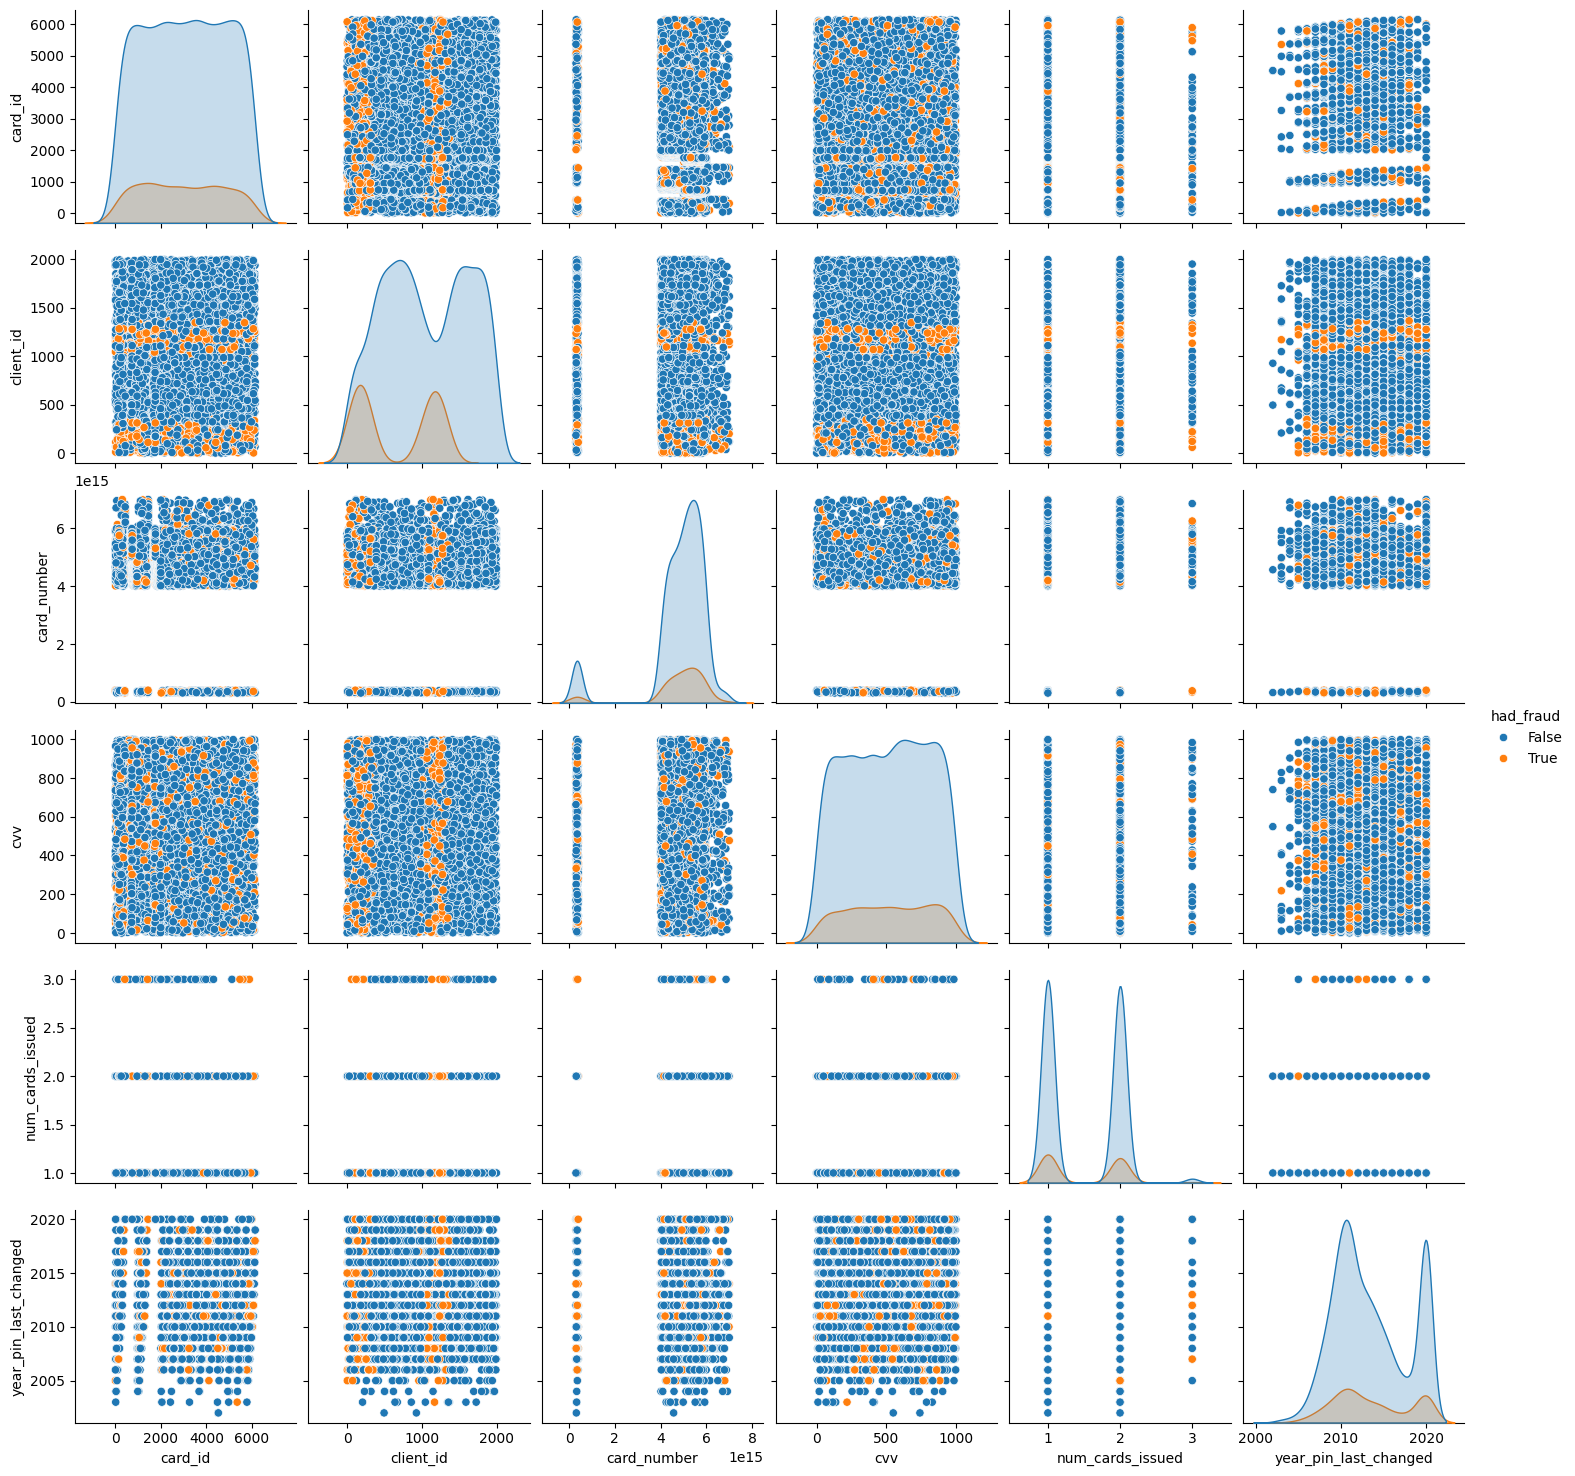

In [16]:
cards_data["had_fraud"] = cards_data["client_id"].isin(fraud_client_ids)
sns.pairplot(data=cards_data, hue="had_fraud")

In [ ]:
cards_data.groupby()

In [ ]:
for col in ['card_brand', 'card_type', 'card_on_dark_web']:
    summary = combined.groupby(col).agg(fraud_rate=('target', lambda x: (x=='Yes').mean() * 100),total_transactions=('target', 'count'),unique_cards=('card_id', 'nunique'))
    print(f'\n{col}:')
    print(summary)


card_brand:
            fraud_rate  total_transactions  unique_cards
card_brand                                              
Amex          0.160644              465626           258
Discover      0.190637              181497           140
Mastercard    0.145205             3871762          2071
Visa          0.135127             2684140          1484

card_type:
                 fraud_rate  total_transactions  unique_cards
card_type                                                    
Credit             0.147851             2231307          1322
Debit              0.132045             4474996          2288
Debit (Prepaid)    0.228498              496722           343

card_on_dark_web:
                  fraud_rate  total_transactions  unique_cards
card_on_dark_web                                              
No                  0.143592             7203025          3953


* Debit (Prepaid) has a high rate

In [22]:
combined['date'] = pd.to_datetime(combined['date'])
combined['years_since_pin_change'] = combined['date'].dt.year - combined['year_pin_last_changed']

corr, p = spearmanr(combined['years_since_pin_change'], combined['target']=='Yes')
print(f'years_since_pin_change: {corr:.4f}')

years_since_pin_change: -0.0004
